Reports directory: /workspace/Hardware/DesignVerification/SystemPerformance/DetectorPhysics/Reports
Figure saved to: /workspace/Hardware/DesignVerification/SystemPerformance/DetectorPhysics/Reports/SpectrumDarkCountMICROFC60035.svg


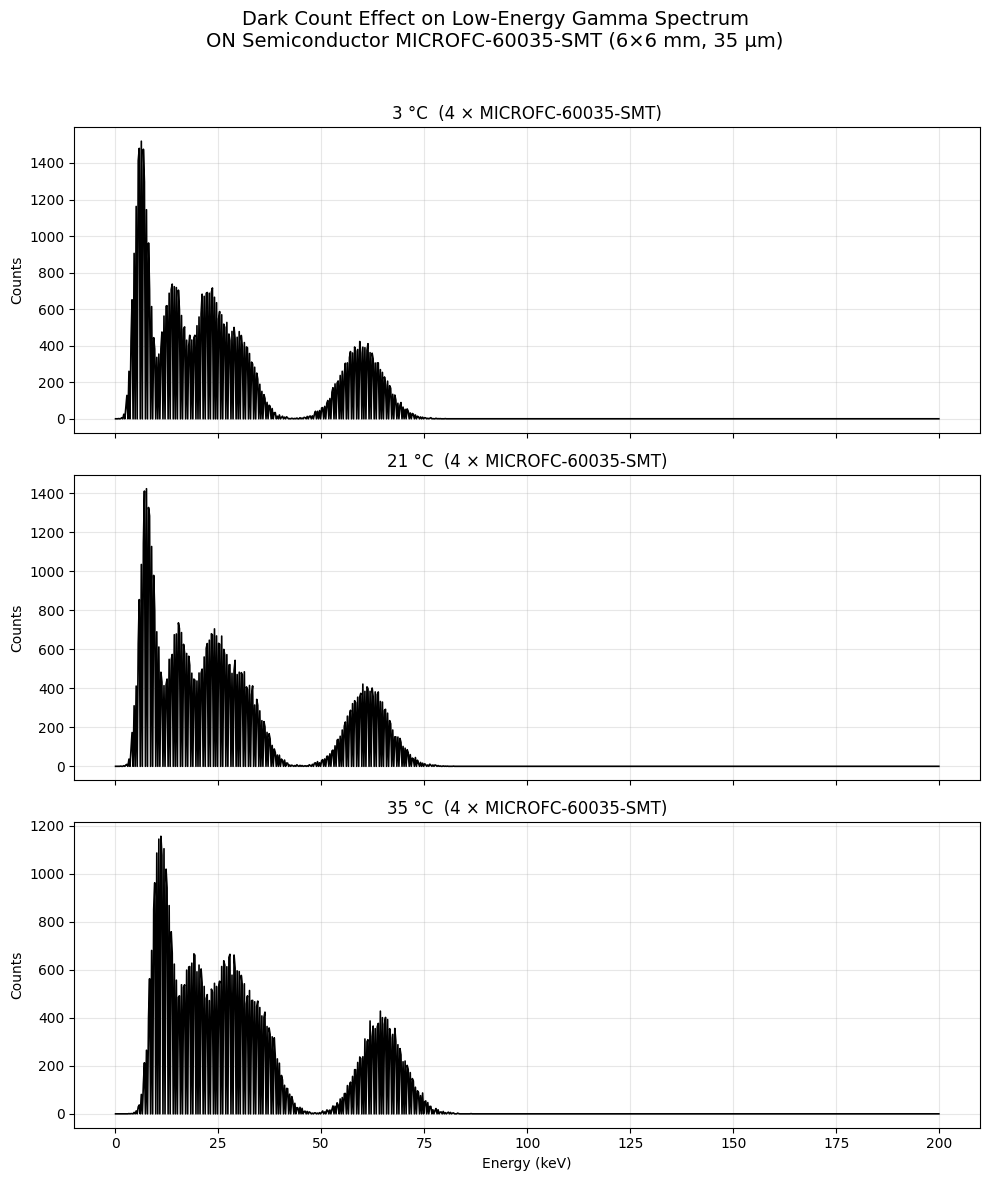

In [3]:
"""
Monte Carlo simulation of low-energy gamma peaks detected by a SiPM array,
including temperature-dependent dark count contribution.

SiPM Device:
    ON Semiconductor C-Series
    Model: MICROFC-60035-SMT
    Active area: 6 mm × 6 mm
    Microcell size: 35 um

Datasheet:
    ON Semiconductor, C-Series SiPM Sensors
    Publication Order Number: MICROC-SERIES/D
    Rev. 9, February 2022

Notes:
    - SiPM intrinsic parameters (DCR, gain, microcell count, temperature coefficients)
      are taken from the above datasheet (explicitly referenced in comments).
    - Scintillation light yield and integration window are system-level assumptions.
    - Crosstalk and afterpulsing are NOT included in this model.
    - Temperature dependence of DCR uses simplified doubling approximation.
"""
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =============================================================================
# Report Directory (Relative to Notebook Location)
# =============================================================================

NOTEBOOK_DIR = Path().resolve()
REPORT_DIR = NOTEBOOK_DIR / "Reports"
REPORT_DIR.mkdir(exist_ok=True)

print(f"Reports directory: {REPORT_DIR}")


# =============================================================================
# Random Generator (Reproducibility)
# =============================================================================

rng = np.random.default_rng(seed=55)


# =============================================================================
# Energy Axis
# =============================================================================

e_max = 200.0  # keV
n_bins = 800
energy_axis = np.linspace(0, e_max, n_bins)


# =============================================================================
# SiPM: MICROFC-60035-SMT (6 mm × 6 mm, 35 µm)
# Datasheet: MICROC-SERIES/D (Rev. 9, Feb 2022)
# =============================================================================

# --- Geometry ---
active_area_mm2 = 6 * 6
# Source: Page 5, Table 2 – Active area (60035: 6 × 6 mm²)

microcell_size_um = 35
# Source: Page 15 – 60035 series (35 µm microcell)

n_microcells = 18980
# Source: Page 5, Table 2 – No. of microcells (60035)

# --- Gain ---
gain_typical = 3e6
# Source: Page 2, Table 1 – Gain @ Vbr + 2.5 V (6 mm, 35 µm)

# --- Dark Count Rate ---
dcr_21c_typ = 1.2e6  # Hz
# Source: Page 3, Table 1 – Dark Count Rate @ 21°C (Typ 1200 kHz)

dcr_21c_max = 3.4e6  # Hz
# Source: Page 3, Table 1 – Dark Count Rate @ 21°C (Max 3400 kHz)

# --- Temperature coefficients ---
temp_coeff_vbr = 21.5e-3  # V/°C
# Source: Page 4 – Temperature dependence of Vbr

temp_coeff_gain = -0.008  # relative change per °C
# Source: Page 4 – Temperature dependence of Gain (−0.8 %/°C)


# =============================================================================
# Detector Array Configuration (System-Level Assumptions)
# =============================================================================

n_sipm = 4  # Number of 6x6 mm SiPMs in array (system configuration)

# Scintillation + optical coupling assumption
pe_per_kev_single = 0.59  # photoelectrons / keV (system-dependent)
pe_per_kev = pe_per_kev_single * n_sipm

integration_time = 1e-6  # seconds (electronics integration window)


# =============================================================================
# Temperature Model (Simplified Approximation)
# =============================================================================

temp_reference = 21.0  # °C (datasheet reference temperature)
dcr_doubling_temp = 10.0  # empirical assumption: DCR doubles every 10 °C


# =============================================================================
# Gamma / X-ray Lines Used in Simulation
# =============================================================================
# Common calibration / environmental sources

isotopes = [
    (5.9, 1.0),    # Fe-55
    (13.5, 0.7),   # Am-241
    (22.0, 0.8),   # Cd-109
    (30.0, 0.6),   # Ba-133
    (59.5, 0.8),   # Am-241
]

events_per_peak = 15000


# =============================================================================
# Simulation Function
# =============================================================================

def simulate_sipm_spectrum(temperature_c: float) -> np.ndarray:
    """
    Simulate detected energy spectrum at a given temperature.
    """

    # Temperature-scaled dark count rate
    # Based on datasheet reference at 21°C
    dcr = dcr_21c_typ * n_sipm * 2 ** (
        (temperature_c - temp_reference) / dcr_doubling_temp
    )

    dark_mean = dcr * integration_time

    all_measured_energies = []

    for energy_kev, intensity in isotopes:

        n_events = int(events_per_peak * intensity)

        mean_signal_pe = energy_kev * pe_per_kev

        signal_pe = rng.poisson(mean_signal_pe, size=n_events)
        dark_pe = rng.poisson(dark_mean, size=n_events)

        total_pe = signal_pe + dark_pe

        measured_energy = total_pe / pe_per_kev

        all_measured_energies.append(measured_energy)

    all_measured_energies = np.concatenate(all_measured_energies)

    spectrum, bin_edges = np.histogram(
        all_measured_energies,
        bins=n_bins,
        range=(0, e_max)
    )
    
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    
    return spectrum, bin_centers


# =============================================================================
# Plotting
# =============================================================================

def plot_spectra(temperatures):

    fig, axes = plt.subplots(len(temperatures), 1,
                             figsize=(10, 12),
                             sharex=True)

    for ax, temp in zip(axes, temperatures):

        spectrum, bin_centers = simulate_sipm_spectrum(temp)

        ax.plot(bin_centers, spectrum,
                color="black", linewidth=1.2)

        ax.set_title(f"{temp:.0f} °C  (4 × MICROFC-60035-SMT)")
        ax.set_ylabel("Counts")
        ax.grid(alpha=0.3)

    axes[-1].set_xlabel("Energy (keV)")

    fig.suptitle(
        "Dark Count Effect on Low-Energy Gamma Spectrum\n"
        "ON Semiconductor MICROFC-60035-SMT (6×6 mm, 35 µm)",
        fontsize=14
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # -------------------------------------------------------------------------
    # Save as SVG to Reports folder
    # -------------------------------------------------------------------------
    output_path = os.path.join(
        REPORT_DIR,
        "SpectrumDarkCountMICROFC60035.svg"
    )

    plt.savefig(
        output_path,
        format="svg",
        bbox_inches="tight"
    )

    print(f"Figure saved to: {output_path}")

    plt.show()


# =============================================================================
# Main
# =============================================================================

if __name__ == "__main__":

    temperatures_to_simulate = [3, 21, 35]
    plot_spectra(temperatures_to_simulate)